In [11]:
import os
from pathlib import Path
from dotenv import load_dotenv

# Find repo root (notebook may run with cwd = repo or notebooks/)
REPO_ROOT = Path.cwd()
if (REPO_ROOT / "notebooks").is_dir() and REPO_ROOT.name != "workspace":
    REPO_ROOT = REPO_ROOT.parent if (REPO_ROOT.parent / ".env").exists() else REPO_ROOT
elif (REPO_ROOT / "notebooks").is_dir() and (REPO_ROOT / ".env").exists():
    pass  # cwd is repo root
elif REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent

load_dotenv(REPO_ROOT / ".env", override=False)

if os.environ.get("ROBOFLOW_API_KEY"):
    os.environ.setdefault("API_KEY", os.environ["ROBOFLOW_API_KEY"])

assert os.environ.get("HF_TOKEN"), "Set HF_TOKEN in .env"
assert os.environ.get("ROBOFLOW_API_KEY"), "Set ROBOFLOW_API_KEY in .env"
print("API keys loaded from .env")

API keys loaded from .env


In [12]:
from pathlib import Path

HOME = REPO_ROOT if "REPO_ROOT" in dir() else Path.cwd()
if HOME.name == "Basketball-player-tracking":
    HOME = HOME.parent
    
print("HOME:", HOME)

SAM2_DIR = HOME / "segment-anything-2-real-time"
assert SAM2_DIR.exists(), f"Missing {SAM2_DIR} — clone SAM2 there first"

HOME: c:\Users\zecab\.gemini\antigravity-ide\scratch


In [13]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "show", "inference-gpu", "supervision", "sports"], check=True)
print("Dependencies OK in active kernel.")

Dependencies OK in active kernel.


In [14]:
SOURCE_VIDEO_DIRECTORY = HOME / "Basketball-player-tracking/data"

SOURCE_VIDEO_PATH = SOURCE_VIDEO_DIRECTORY / "boston-celtics-new-york-knicks-game-1-q2-10.36-10.32.mp4"

In [15]:
TEAM_ROSTERS = {
  "New York Knicks": {
    "55": "Hukporti",
    "1": "Payne",
    "0": "Wright",
    "11": "Brunson",
    "3": "Hart",
    "32": "Towns",
    "44": "Shamet",
    "25": "Bridges",
    "2": "McBride",
    "23": "Robinson",
    "8": "Anunoby",
    "4": "Dadiet",
    "5": "Achiuwa",
    "13": "Kolek"
  },
  "Boston Celtics": {
    "42": "Horford",
    "55": "Scheierman",
    "9": "White",
    "20": "Davison",
    "7": "Brown",
    "0": "Tatum",
    "27": "Walsh",
    "4": "Holiday",
    "8": "Porzingis",
    "40": "Kornet",
    "88": "Queta",
    "11": "Pritchard",
    "30": "Hauser",
    "12": "Craig",
    "26": "Tillman"
  }
}

TEAM_COLORS = {
    "New York Knicks": "#006BB6",
    "Boston Celtics": "#007A33"
}

In [16]:
from IPython.display import Video
from typing import Dict, List, Optional, Union, Iterable, Tuple
from operator import itemgetter

import cv2
import numpy as np
import torch
from tqdm import tqdm

import supervision as sv
from inference import get_model
from sports import (
    clean_paths,
    ConsecutiveValueTracker,
    TeamClassifier,
    MeasurementUnit,
    ViewTransformer
)

In [18]:
PLAYER_DETECTION_MODEL_ID = "basketball-player-detection-3-ycjdo/4"
PLAYER_DETECTION_MODEL_CONFIDENCE = 0.4
PLAYER_DETECTION_MODEL_IOU_THRESHOLD = 0.9
PLAYER_DETECTION_MODEL = get_model(model_id=PLAYER_DETECTION_MODEL_ID)

COLOR = sv.ColorPalette.from_hex([
    "#ffff00", "#ff9b00", "#ff66ff", "#3399ff", "#ff66b2", "#ff8080",
    "#b266ff", "#9999ff", "#66ffff", "#33ff99", "#66ff66", "#99ff00"
])

%cd $HOME/segment-anything-2-real-time
import sys
import os

# Ensure the current directory is at the front of sys.path
current_dir = os.getcwd()
if current_dir not in sys.path:
    sys.path.insert(0, current_dir)

# If 'sam2' was previously imported from dist-packages, remove it from sys.modules
# to force Python to re-import it from the updated sys.path
if 'sam2' in sys.modules:
    del sys.modules['sam2']
    # Also delete submodules if any
    for module_name in list(sys.modules.keys()):
        if module_name.startswith('sam2.'):
            del sys.modules[module_name]

from sam2.build_sam import build_sam2_camera_predictor

SAM2_CHECKPOINT = "checkpoints/sam2.1_hiera_large.pt"
SAM2_CONFIG = "configs/sam2.1/sam2.1_hiera_l.yaml"

predictor = build_sam2_camera_predictor(SAM2_CONFIG, SAM2_CHECKPOINT)

c:\Users\zecab\.gemini\antigravity-ide\scratch\segment-anything-2-real-time


In [19]:
from __future__ import annotations

class SAM2Tracker:
    def __init__(self, predictor) -> None:
        self.predictor = predictor
        self._prompted = False

    def prompt_first_frame(self, frame: np.ndarray, detections: sv.Detections) -> None:
        if len(detections) == 0:
            raise ValueError("detections must contain at least one box")

        if detections.tracker_id is None:
            detections.tracker_id = list(range(1, len(detections) + 1))

        with torch.inference_mode(), torch.autocast("cuda", dtype=torch.bfloat16):
            self.predictor.load_first_frame(frame)
            for xyxy, obj_id in zip(detections.xyxy, detections.tracker_id):
                bbox = np.asarray([xyxy], dtype=np.float32)
                self.predictor.add_new_prompt(
                    frame_idx=0,
                    obj_id=int(obj_id),
                    bbox=bbox,
                )

        self._prompted = True

    def propagate(self, frame: np.ndarray) -> sv.Detections:
        if not self._prompted:
            raise RuntimeError("Call prompt_first_frame before propagate")

        with torch.inference_mode(), torch.autocast("cuda", dtype=torch.bfloat16):
            tracker_ids, mask_logits = self.predictor.track(frame)

        tracker_ids = np.asarray(tracker_ids, dtype=np.int32)
        masks = (mask_logits > 0.0).cpu().numpy()
        masks = np.squeeze(masks).astype(bool)

        if masks.ndim == 2:
            masks = masks[None, ...]

        masks = np.array([
            sv.filter_segments_by_distance(mask, relative_distance=0.03, mode="edge")
            for mask in masks
        ])

        xyxy = sv.mask_to_xyxy(masks=masks)
        detections = sv.Detections(xyxy=xyxy, mask=masks, tracker_id=tracker_ids)
        return detections

    def reset(self) -> None:
        self._prompted = False

In [21]:
STRIDE = 30
PLAYER_CLASS_IDS = [3, 4, 5, 6, 7] # player, player-in-possession, player-jump-shot, player-layup-dunk, player-shot-block
crops = []

# video_path in sv.list_files_with_extensions(SOURCE_VIDEO_DIRECTORY, extensions=["mp4", "avi", "mov"]):
# frame_generator = sv.get_video_frames_generator(source_path=SOURCE_VIDEO_PATH, stride=STRIDE)

# for frame in tqdm(frame_generator):

#     result = PLAYER_DETECTION_MODEL.infer(frame, confidence=PLAYER_DETECTION_MODEL_CONFIDENCE, iou_threshold=PLAYER_DETECTION_MODEL_IOU_THRESHOLD, class_agnostic_nms=True)[0]
#     detections = sv.Detections.from_inference(result)
#     detections = detections[np.isin(detections.class_id, PLAYER_CLASS_IDS)]

#     boxes = sv.scale_boxes(xyxy=detections.xyxy, factor=0.4)
#     for box in boxes:
#         crops.append(sv.crop_image(frame, box))

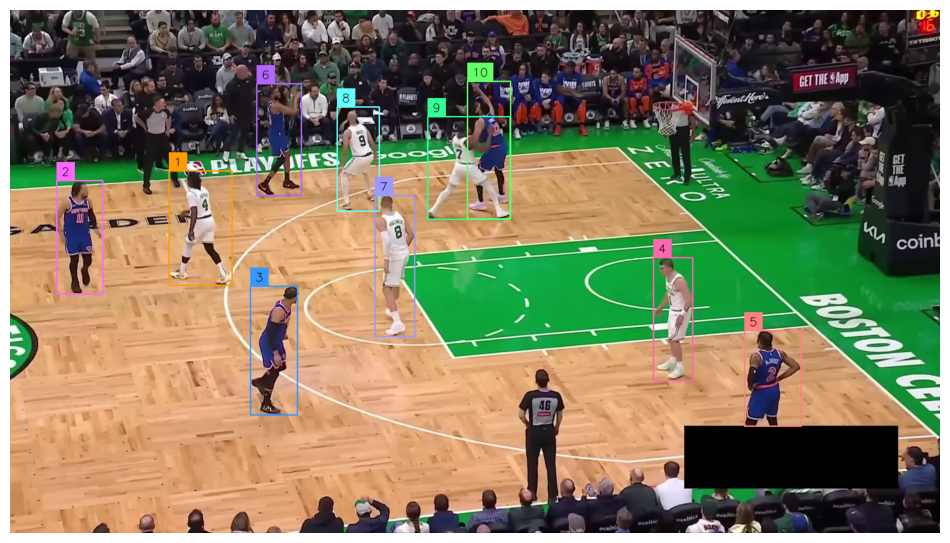


Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).


Processing video:   0%|          | 0/109 [00:00<?, ?it/s]


Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
'ffmpeg' n'est pas reconnu en tant que commande interne
ou externe, un programme ex�cutable ou un fichier de commandes.


In [22]:
TARGET_VIDEO_PATH = HOME / f"{SOURCE_VIDEO_PATH.stem}-mask{SOURCE_VIDEO_PATH.suffix}"
TARGET_VIDEO_COMPRESSED_PATH = HOME / f"{TARGET_VIDEO_PATH.stem}-compressed{TARGET_VIDEO_PATH.suffix}"

# define team annotators

mask_annotator = sv.MaskAnnotator(
    color=COLOR,
    color_lookup=sv.ColorLookup.TRACK,
    opacity=0.5)
box_annotator = sv.BoxAnnotator(
    color=COLOR,
    color_lookup=sv.ColorLookup.TRACK,
    thickness=2
)
id_annotator = sv.LabelAnnotator(
    color=COLOR,
    color_lookup=sv.ColorLookup.TRACK,
    text_color=sv.Color.BLACK,
    text_scale=0.8
)

# we use RF-DETR model to aquire future SAM2 prompt

frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH)
frame = next(frame_generator)

result = PLAYER_DETECTION_MODEL.infer(frame, confidence=PLAYER_DETECTION_MODEL_CONFIDENCE, iou_threshold=PLAYER_DETECTION_MODEL_IOU_THRESHOLD)[0]
detections = sv.Detections.from_inference(result)
detections = detections[np.isin(detections.class_id, PLAYER_CLASS_IDS)]
detections.tracker_id = np.arange(1, len(detections.class_id) + 1)

annotated_frame = frame.copy()
annotated_frame = box_annotator.annotate(scene=annotated_frame, detections=detections)
annotated_frame = id_annotator.annotate(scene=annotated_frame, detections=detections, labels=detections.tracker_id)


sv.plot_image(annotated_frame)

# we prompt SAM2 using RF-DETR model detections

tracker = SAM2Tracker(predictor)
tracker.prompt_first_frame(frame, detections)

# we propagate tacks across all video frames

def callback(frame: np.ndarray, index: int) -> np.ndarray:
    detections = tracker.propagate(frame)
    annotated_frame = frame.copy()
    annotated_frame = mask_annotator.annotate(scene=annotated_frame, detections=detections)
    annotated_frame = box_annotator.annotate(scene=annotated_frame, detections=detections)
    annotated_frame = id_annotator.annotate(scene=annotated_frame, detections=detections, labels=detections.tracker_id)
    return annotated_frame

sv.process_video(
    source_path=SOURCE_VIDEO_PATH,
    target_path=TARGET_VIDEO_PATH,
    callback=callback,
    show_progress=True
)

!ffmpeg -y -loglevel error -i {TARGET_VIDEO_PATH} -vcodec libx264 -crf 28 {TARGET_VIDEO_COMPRESSED_PATH}


In [25]:
STRIDE = 50

crops = []

#for video_path in sv.list_files_with_extensions(SOURCE_VIDEO_DIRECTORY, extensions=["mp4", "avi", "mov"]):
frame_generator = sv.get_video_frames_generator(source_path=SOURCE_VIDEO_PATH, stride=STRIDE)

for frame in tqdm(frame_generator):

    result = PLAYER_DETECTION_MODEL.infer(frame, confidence=PLAYER_DETECTION_MODEL_CONFIDENCE, iou_threshold=PLAYER_DETECTION_MODEL_IOU_THRESHOLD, class_agnostic_nms=True)[0]
    detections = sv.Detections.from_inference(result)
    detections = detections[np.isin(detections.class_id, PLAYER_CLASS_IDS)]

    boxes = sv.scale_boxes(xyxy=detections.xyxy, factor=0.4)
    for box in boxes:
        crops.append(sv.crop_image(frame, box))

team_classifier = TeamClassifier(device="cuda")
team_classifier.fit(crops)

3it [00:03,  1.05s/it]


Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

Embedding extraction: 1it [00:00,  1.05it/s]


In [ ]:
frames_history = []
detections_history = []

number_validator = ConsecutiveValueTracker(n_consecutive=3)
team_validator = ConsecutiveValueTracker(n_consecutive=1)

frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH)
frame = next(frame_generator)

# we use RF-DETR model to aquire future SAM2 prompt

result = PLAYER_DETECTION_MODEL.infer(frame, confidence=PLAYER_DETECTION_MODEL_CONFIDENCE, iou_threshold=PLAYER_DETECTION_MODEL_IOU_THRESHOLD)[0]
detections = sv.Detections.from_inference(result)
detections = detections[np.isin(detections.class_id, PLAYER_CLASS_IDS)]
detections.tracker_id = np.arange(1, len(detections.class_id) + 1)

# we determine the team for each player and assign a team ID to every detection

boxes = sv.scale_boxes(xyxy=detections.xyxy, factor=0.4)
crops = [sv.crop_image(frame, box) for box in boxes]
TEAMS = np.array(team_classifier.predict(crops))

team_validator.update(tracker_ids=detections.tracker_id, values=TEAMS)

# we prompt SAM2 using RF-DETR model detections

tracker = SAM2Tracker(predictor)
tracker.prompt_first_frame(frame, detections)

# we propagate tacks across all video frames

frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH)

for index, frame in tqdm(enumerate(frame_generator)):
    player_detections = tracker.propagate(frame)
    frames_history.append(frame)
    detections_history.append(player_detections)

    # we perform number recognition at specific frame intervals

    if index % 5 == 0:
        frame_h, frame_w, *_ = frame.shape

        # we use RF-DETR model to detect numbers

        result = PLAYER_DETECTION_MODEL.infer(frame, confidence=PLAYER_DETECTION_MODEL_CONFIDENCE, iou_threshold=PLAYER_DETECTION_MODEL_IOU_THRESHOLD)[0]
        number_detections = sv.Detections.from_inference(result)
        number_detections = number_detections[number_detections.class_id == NUMBER_CLASS_ID]
        number_detections.mask = sv.xyxy_to_mask(boxes=number_detections.xyxy, resolution_wh=(frame_w, frame_h))

        # we crop out numbers detection and run recognition model

        number_crops = [
            sv.crop_image(frame, xyxy)
            for xyxy
            in sv.clip_boxes(sv.pad_boxes(xyxy=number_detections.xyxy, px=10, py=10), (frame_w, frame_h))
        ]
        numbers = [
            NUMBER_RECOGNITION_MODEL.predict(number_crop, NUMBER_RECOGNITION_MODEL_PROMPT)[0]
            for number_crop
            in number_crops
        ]

        # we use mask IoS to match numbers with players

        iou = sv.mask_iou_batch(
            masks_true=player_detections.mask,
            masks_detection=number_detections.mask,
            overlap_metric=sv.OverlapMetric.IOS
        )

        pairs = coords_above_threshold(iou, 0.9)

        if pairs:

            player_idx, number_idx = zip(*pairs)
            player_idx = [i + 1 for i in player_idx]
            number_idx = list(number_idx)

            # we update number_validator state

            numbers = [numbers[int(i)] for i in number_idx]
            number_validator.update(tracker_ids=player_idx, values=numbers)

Embedding extraction: 1it [00:00,  1.81it/s]

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
0it [00:00, ?it/s]UserWarning: cannot import name '_C' from 'sam2' (c:\Users\zecab\.gemini\antigravity-ide\scratch\segment-anything-2-real-time\sam2\__init__.py)

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
0it [00:02, ?it/s]


NameError: name 'NUMBER_CLASS_ID' is not defined

In [32]:
%load_ext autoreload
%autoreload 2

from src2.one_possession import run_one_possession, PossessionCfg

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [34]:
cfg = PossessionCfg(
    confidence=PLAYER_DETECTION_MODEL_CONFIDENCE,
    iou_threshold=PLAYER_DETECTION_MODEL_IOU_THRESHOLD,
    player_class_ids=PLAYER_CLASS_IDS,
    number_class_id=2,
)

mask_ann = sv.MaskAnnotator(color=COLOR, color_lookup=sv.ColorLookup.TRACK, opacity=0.5)
label_ann = sv.LabelAnnotator(color=COLOR, color_lookup=sv.ColorLookup.TRACK,
                              text_color=sv.Color.BLACK, text_scale=0.8)

info = sv.VideoInfo.from_video_path(SOURCE_VIDEO_PATH)
with sv.VideoSink(str(TARGET_VIDEO_PATH), info) as sink:
    def write(frame, det):
        out = mask_ann.annotate(frame.copy(), det)
        out = label_ann.annotate(out, det, labels=[f"#{t}" for t in det.tracker_id])
        sink.write_frame(out)

    tracks, validators = run_one_possession(
        sv.get_video_frames_generator(SOURCE_VIDEO_PATH),
        PLAYER_DETECTION_MODEL, predictor, cfg,
        team_classifier=team_classifier,
        on_frame=write,
    )

print(tracks.groupby(["team", "track_id"]).size())

possession 0: 0it [00:00, ?it/s]
Embedding extraction: 0it [00:00, ?it/s]
Embedding extraction: 1it [00:00,  3.02it/s]

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
possession 0: 1it [00:02,  2.76s/it]UserWarning: cannot import name '_C' from 'sam2' (c:\Users\zecab\.gemini\antigravity-ide\scratch\segment-anything-2-real-time\sam2\__init__.py)

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
possession 0: 109it [07:40,  4.23s/it]


team  track_id
0     2            89
      3           109
      5           109
      6           109
      10           96
1     1           109
      4           109
      7           109
      8           109
      9           109
dtype: int64


In [54]:
print(TARGET_VIDEO_COMPRESSED_PATH)

c:\Users\zecab\.gemini\antigravity-ide\scratch\boston-celtics-new-york-knicks-game-1-q2-10.36-10.32-mask-compressed.mp4


In [75]:
"""Two-frame hard-cut detection from HSV histograms and pixel similarity."""

from __future__ import annotations

import cv2
import numpy as np

THRESHOLD_HIGH = 0.996
THRESHOLD_LOW = 0.70
THRESHOLD_PIXEL = 0.85


def compare_histograms(
    current_frame: np.ndarray,
    previous_frame: np.ndarray,
    bins: int = 32,
) -> tuple[float, np.ndarray, np.ndarray]:
    """Return HSV Hue-Saturation histogram correlation for two BGR frames."""
    hsv_current = cv2.cvtColor(current_frame, cv2.COLOR_BGR2HSV)
    hsv_previous = cv2.cvtColor(previous_frame, cv2.COLOR_BGR2HSV)
    hist_current = cv2.calcHist(
        [hsv_current], [0, 1], None, [bins, bins], [0, 180, 0, 256]
    )
    hist_previous = cv2.calcHist(
        [hsv_previous], [0, 1], None, [bins, bins], [0, 180, 0, 256]
    )
    cv2.normalize(hist_current, hist_current)
    cv2.normalize(hist_previous, hist_previous)
    correlation = float(
        cv2.compareHist(hist_current, hist_previous, cv2.HISTCMP_CORREL)
    )
    return correlation, hist_current, hist_previous


def pixel_difference(frame1: np.ndarray, frame2: np.ndarray) -> float:
    """Return grayscale pixel similarity in ``[0, 1]`` (1 = identical)."""
    gray1 = cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(frame2, cv2.COLOR_BGR2GRAY)
    difference = cv2.absdiff(gray1, gray2)
    return float(1 - difference.mean() / 255)


def detect_hard_cuts(
    frame_idx: int,
    frame: np.ndarray,
    previous_frame: np.ndarray,
    threshold_high: float = THRESHOLD_HIGH,
    threshold_low: float = THRESHOLD_LOW,
    threshold_pixel: float = THRESHOLD_PIXEL,
) -> bool:
    """True when the current pair looks like a hard camera cut."""
    correlation, _, _ = compare_histograms(frame, previous_frame)
    similarity = pixel_difference(frame, previous_frame)
    if (
        correlation < threshold_high
        and correlation > threshold_low
        and similarity < threshold_pixel
    ):
        print(
            f"Hard cut detected after frame {frame_idx}, "
            f"correlation: {correlation}, pixel difference: {similarity}"
        )
        return True
    return False

import numpy as np

class HardCutDetector:
    """Looks at every frame and remembers if a hard cut happened."""

    def __init__(self, min_gap: int = 15):
        self.min_gap = min_gap           # ignore cuts closer than N source frames to the last one
        self.previous_frame = None
        self.last_cut = -min_gap
        self.pending = False             # True if a cut happened since the last pop()
        self.cuts: list[int] = []        # source frame indices of all cuts

    def update(self, frame: np.ndarray, source_idx: int) -> bool:
        """Call on EVERY source frame. Returns True if this frame is a cut."""
        is_cut = (
            self.previous_frame is not None
            and source_idx - self.last_cut >= self.min_gap
            and detect_hard_cuts(source_idx, frame, self.previous_frame)
        )
        self.previous_frame = frame
        if is_cut:
            self.last_cut = source_idx
            self.cuts.append(source_idx)
            self.pending = True
        return is_cut

    def pop(self) -> bool:
        """True if a cut happened since the last call, then resets the flag."""
        flag, self.pending = self.pending, False
        return flag


In [76]:
import supervision as sv
from tqdm.auto import tqdm

detector = HardCutDetector()
for source_idx, frame in enumerate(tqdm(sv.get_video_frames_generator(SOURCE_VIDEO_PATH,stride=3))):
    detector.update(frame, source_idx)

print("cuts at source frames:", detector.cuts)

0it [00:00, ?it/s]

Hard cut detected after frame 14, correlation: 0.9952266499105041, pixel difference: 0.7806001876059065
Hard cut detected after frame 35, correlation: 0.9886372691438174, pixel difference: 0.8046960746489954
cuts at source frames: [14, 35]


0it [00:00, ?it/s]

53 frame pairs read


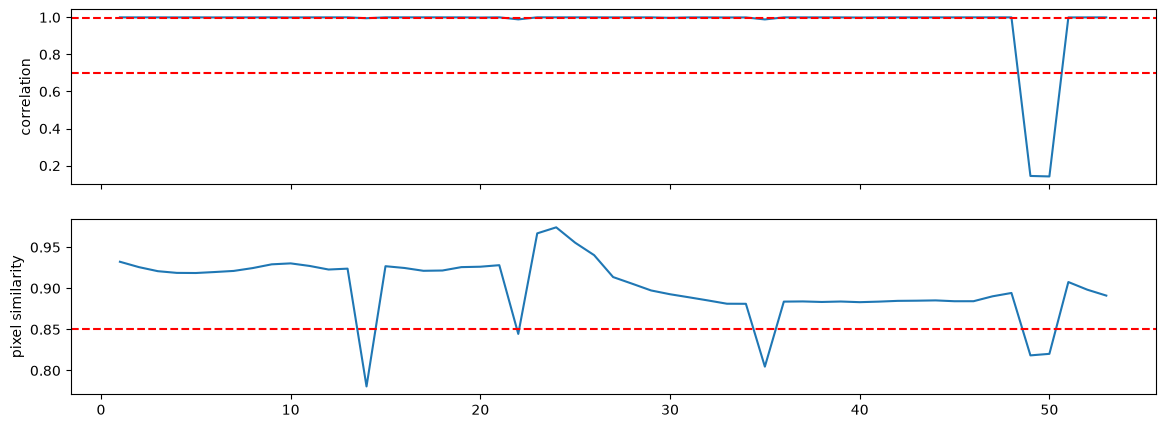

,frame,corr,sim
13,14,0.995227,0.780600
34,35,0.988637,0.804696
48,49,0.144266,0.818378
49,50,0.141700,0.820247
21,22,0.988905,0.844487
33,34,0.999446,0.881129
32,33,0.999194,0.881224
39,40,0.998865,0.883116
37,38,0.999742,0.883367
40,41,0.999623,0.883774


In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import supervision as sv
from tqdm.auto import tqdm

rows = []
previous = None
for idx, frame in enumerate(tqdm(sv.get_video_frames_generator(SOURCE_VIDEO_PATH,stride=3))):
    if previous is not None:
        corr, _, _ = compare_histograms(frame, previous)
        sim = pixel_difference(frame, previous)
        rows.append(dict(frame=idx, corr=corr, sim=sim))
    previous = frame

diag = pd.DataFrame(rows)
print(len(diag), "frame pairs read")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
ax1.plot(diag["frame"], diag["corr"]); ax1.set_ylabel("correlation")
ax1.axhline(THRESHOLD_HIGH, color="r", ls="--"); ax1.axhline(THRESHOLD_LOW, color="r", ls="--")
ax2.plot(diag["frame"], diag["sim"]); ax2.set_ylabel("pixel similarity")
ax2.axhline(THRESHOLD_PIXEL, color="r", ls="--")
plt.show()

diag.sort_values("sim").head(10)

In [ ]:
import numpy as np
import supervision as sv
import torch
import pandas as pd
from tqdm.auto import tqdm


def run_one_possession(frames, possession_id=0, on_frame=None, max_frames=None, check_cuts=False):
    tracker = SAM2Tracker(predictor)
    team_of = {}
    prompted = False
    rows = []
    previous_frame = None

    for i, frame in enumerate(tqdm(frames, total=max_frames)):

        # stop after max_frames frames (checked first, so it also works on skipped frames)
        if max_frames is not None and i >= max_frames:
            break

        # cut check on every frame (30 fps), before the stride skip
        if check_cuts and previous_frame is not None:
            detect_hard_cuts(i, frame, previous_frame)   # prints when a cut is found
        previous_frame = frame

        if not prompted:
            # 1. detect players with RF-DETR
            result = PLAYER_DETECTION_MODEL.infer(
                frame,
                confidence=PLAYER_DETECTION_MODEL_CONFIDENCE,
                iou_threshold=PLAYER_DETECTION_MODEL_IOU_THRESHOLD,
            )[0]
            detections = sv.Detections.from_inference(result)
            detections = detections[np.isin(detections.class_id, PLAYER_CLASS_IDS)]

            # wait for a frame with 10 players (max 15 frames = 0.5 s at 30 fps)
            if len(detections) == 0 or (len(detections) < 10 and i < 15):
                continue

            detections.tracker_id = np.arange(1, len(detections) + 1)

            # 2. teams, once
            boxes = sv.scale_boxes(xyxy=detections.xyxy, factor=0.4)
            crops = [sv.crop_image(frame, box) for box in boxes]
            teams = team_classifier.predict(crops)
            team_of = dict(zip(detections.tracker_id.tolist(), list(teams)))

            # 3. prompt SAM2
            tracker.prompt_first_frame(frame, detections)
            prompted = True

        else:
            # 4. propagate
            detections = tracker.propagate(frame)
            detections = detections[detections.area > 0]
            sv.plot_image(frame)

        if on_frame is not None:
            on_frame(frame, detections)

        for (x1, y1, x2, y2), tid in zip(detections.xyxy, detections.tracker_id):
            rows.append(dict(
                possession_id=possession_id, frame=i, track_id=int(tid),
                team=team_of.get(int(tid), -1),
                x1=x1, y1=y1, x2=x2, y2=y2,
            ))

    torch.cuda.empty_cache()
    return pd.DataFrame(rows)